# Level 2 — Task 1: Logistic Regression for Binary Classification

### Notebook Overview

This project uses the processed datasets generated during Task 1 to build a Logistic Regression model that predicts customer churn.

The main goals are to:
- Train a Logistic Regression classifier model.
- Evaluate the model using classification metrics.
- Interpret coefficients and odds ratio.
- Grasp how prediction thresholds affect precision and recall.
- Use AUC-ROC (Area Under the Receiver Operating Characteristic Curve) to evaluate model on imbalanced dataset.

In [1]:
import sys 
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

ROOT = Path.cwd().parents[2] # Go up two directories

# Add project root to Python's module search path so notebook can import from src/
if str(ROOT) not in sys.path: # Prevent duplicate path entries
    sys.path.append(str(ROOT)) # Add project root

DATA_DIR = ROOT / "data"

In [2]:
# Processed data directory
PROCESSED_DIR = DATA_DIR / "processed" / "churn"

# Load training data
X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv")

# Load target data
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze()

# Verify datasets loaded correctly
for obj, label in [(X_train, "X_train"), (X_test, "X_test"), 
                   (y_train, "y_train"), (y_test, "y_test")]:
    print(f"{label} shape: {obj.shape}")

print(f"\ny_train type: {type(y_train)}")
print(f"y_test type: {type(y_test)}")

X_train shape: (2666, 14)
X_test shape: (667, 14)
y_train shape: (2666,)
y_test shape: (667,)

y_train type: <class 'pandas.Series'>
y_test type: <class 'pandas.Series'>


In [3]:
print("Training target distribution:")
print(y_test.value_counts(normalize=True)[False])

print("\nTesting target distribution:")
print(y_train.value_counts(normalize=True)[False])

Training target distribution:
0.8575712143928036

Testing target distribution:
0.854463615903976


## Logistic Regression

Despite its name, Logistic Regression is a **classification** algorithm used to predict the probability of a binary outcome. Unlike Linear Regression, which predicts continuous values, Logistic Regression uses the **sigmoid function** to confine its output to a probability between 0 and 1.

For customer churn prediction:
- Values near **0** indicate a low probability the customer will churn
- Values near **1** indicate a high probability the customer will churn

After estimating the probability, the model converts it into a class prediction using a chosen threshold (default is 0.5). The optimal threshold depends on the problem. Churn predictions might lower it if missing a churner is more costly than a false alarm.

Advantages of Logistic Regression:
- Fast to train & easy to interpret
- Predicts probabilities
- Allows analysis of feature importance through model coefficients

In [4]:
# Create baseline model
lr = LogisticRegression(
    random_state=42,
    max_iter=1000 # set high to avoid convergence issues
)

lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Logistic regression iterates by continually updating it's weights to minimize error/maximize accuracy. Setting max iterations (`max_iter`) to a higher value than its default of 100 ensures the model doesn't stop prematurely before the optimization algorithm has converged to the best solution. 


Setting max iterations (`max_iter`) to a higher value than its default of 100 ensures the model doesn't stop prematurely before the optimization algorithm has converged to the best parameters.

## Predicted Probabilities

One advantage of Logistic Regression is that it outputs/predicts probabilities rather than only class labels.

The model estimates the **probability** that a customer belongs to the positive class (churn = 1).

These probabilities are then converted into class predictions by applying a threshold, adjustable depending on the cost of false positives versus false negatives.


In [5]:
# Predict churn probabilities
y_prob = lr.predict_proba(X_test)

y_prob_df = pd.DataFrame(
    y_prob,
    columns=["Not Churn","Churn"], 
    index=X_test.index # same index as X_test
)

# Notice each row sums to 1
y_prob_df.round(2).head(10) # rounded for readability

,Not Churn,Churn
0,0.84,0.16
1,0.78,0.22
2,0.39,0.61
3,0.98,0.02
4,0.94,0.06
5,0.99,0.01
6,0.78,0.22
7,0.67,0.33
8,0.87,0.13
9,0.84,0.16


Rather than outputting hard class labels (0 or 1), Logistic Regression returns a probability for each class.
Row 2 for insance, the model estimates a 61% probability that the customer **will** churn, and a 39% probability that they will **not**.



In [6]:
# Inspect y_prob_df
display(y_prob_df["Churn"].describe())

y_train.value_counts(normalize=True)

count    667.000000
mean       0.143402
std        0.155601
min        0.002427
25%        0.040868
50%        0.081369
75%        0.180889
max        0.787595
Name: Churn, dtype: float64

Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64

Looking at the predicted `y_prob` DataFrame, the model's average (mean) churn probability is **14.3%**, which almost matches the actual churn ratio in training set of **14.6%**. 

The median is only **8.1%** which means for most customer entries, the model predicted a very low probability of churning. Even the 75th percentile is **18.1%** which meant 75% of customers have low predicted churn probability.

We infer the Logistic Regression model is relatively conservative. The model is giving probability estimates that reflect he imbalanced churn dataset. Most customers are predicted as low churn risk.

## Class Predictions

While Logistic Regression predicts probabilities, we'll need final class predictions. The workflow for Logistic Regression models is to predict probabilities and after setting a threshold for class labels.

By default, Scikit-Learn uses a threshold of 0.5:

- Probability ≥ 0.5: Churn
- Probability < 0.5: Not Churn

These predictions will then be compared against the true labels to evaluate model performance.

In [7]:
# Generate class predictions
y_pred = lr.predict(X_test)

In [8]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8546
Precision: 0.4722
Recall   : 0.1789
F1 Score : 0.2595


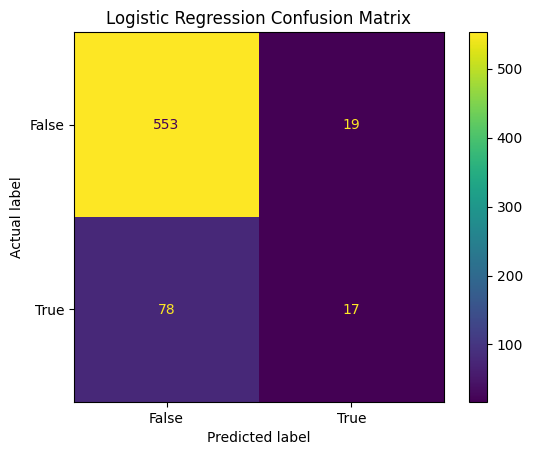

In [9]:
# Initialize confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot cm
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr.classes_
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
disp.ax_.set_ylabel("Actual label")
plt.show()

The results from the confusion matrix:

- 553 actually `false`, predicted **false** (TN)

- 19 actually `false`, predicted **true** (FP)

- 78 actually `true`, predicted **false** (FN)

- 17 actually `true`, predicted **true** (TP)

Evaluation: the model is great at predicting non-churners, as only 19 of the true predictions were actually false. However, of the 95 actual churners, the model only correctly identified 17. 17/95 = ~17.9%, meaning the model caught less than 1 in 5 customers who actually churned. This is worse than even the initial KNN classifie scores.

This confirms the model is highly conservative, rarely predicting churn, which keeps false alarms 
low (only 19) but causes the majority of actual churners to go undetected.

For a churn prediction problem, this is a significant limitation if retaining at-risk customers is 
a business priority. Lowering the classification threshold would likely improve recall at the cost 
of more false positives.

### KNN vs. Logistic Regression

Despite Logistic Regression being the more interpretable model, KNN outperformed it in this 
case. This suggests the decision boundary for churn in this dataset may not be strictly linear, 
which favors a distance-based approach like KNN.

It is imperative to understand that Logistic Regression isn't neccesarily worse than KNN, as the churn dataset doesn't show apparent linear patterns as churn behaviors have many factors. Good practice would be to realize that both models "view" the data differently.

In [10]:
# Print full classification report
print(classification_report(y_test, y_pred))

# Display report as a DataFrame
results = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T # .T transpose

results

              precision    recall  f1-score   support

       False       0.88      0.97      0.92       572
        True       0.47      0.18      0.26        95

    accuracy                           0.85       667
   macro avg       0.67      0.57      0.59       667
weighted avg       0.82      0.85      0.83       667



,precision,recall,f1-score,support
False,0.876387,0.966783,0.919368,572.000000
True,0.472222,0.178947,0.259542,95.000000
accuracy,0.854573,0.854573,0.854573,0.854573
macro avg,0.674304,0.572865,0.589455,667.000000
weighted avg,0.818822,0.854573,0.825390,667.000000


### Classification Thresholds and Business Tradeoffs

The threshold controls how conservative or aggressive the model is when predicting the positive class.

**Hospital Disease Screening**
- Missing a disease is detrimental.
- Use a lower threshold (e.g., 0.20).
- Increases recall by identifying more potential cases.
- Also increases false positives and lowers precision, tradeoff is justified however.

**Email Spam Detection**

- Incorrectly flagging crucial legitimate emails is detrimental.
- Use a higher threshold (e.g., 0.90).
- Increases precision by reducing false positives, being more convervative of labeling an email as spam.
- May miss some spam messages, resulting in lower recall score.

**Customer Churn Prediction**

- Missing a customer who is about to leave (churn) is often more costly than incorrectly flagging a loyal customer.
- A lower threshold may be preferable because it can identify more at-risk to churn customers.

### Threshold Tradeoff

As the threshold **decreases** in the churn dataset:

- Recall increases because more customers are classified as churners.
- False positives increase because more non-churn customers are incorrectly flagged.

As the threshold **increases**:

- Recall decreases because fewer customers are classified as churners.
- False positives decrease because the model becomes more conservative.

This tradeoff is a fundamental part of classification problems. Rather than evaluating only a single threshold, we can evaluate model performance across all possible thresholds using the ROC Curve.


In [11]:
# Index of Churn probability
y_prob_churn = y_prob[:, 1]

print(y_prob_churn[:10].round(2)) # rounded for readability

[0.16 0.22 0.61 0.02 0.06 0.01 0.22 0.33 0.13 0.16]


### ROC Curve and AUC

When we change the threshold in our confusion matrix, each version of the model produces a different 
confusion matrix. The Receiver Operating Characteristic (ROC) Curve evaluates model performance 
across all possible classification thresholds.

The ROC curve plots:
- False Positive Rate (FPR) on the x-axis
- True Positive Rate (Recall) on the y-axis

A model that achieves high recall while maintaining a low false positive rate will produce a curve 
closer to the upper-left corner. The diagonal line from (0,0) to (1,1) represents a model that 
guesses randomly. Any useful model's ROC curve should be above that line.

The Area Under the Curve (AUC) summarizes overall model performance:
- AUC = 0.5 indicates **random** guessing (the diagonal line).
- AUC = 1.0 indicates **perfect** classification.
- AUC < 0.5 means the model performs worse then literally just **guessing randomly**.

Intuitively, AUC represents the probability that the model scores a random churner higher than a 
random non-churner. Higher AUC values indicate better class separation.

In [12]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_churn)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob_churn)

print(f"AUC Score: {auc}")

AUC Score: 0.8253588516746411


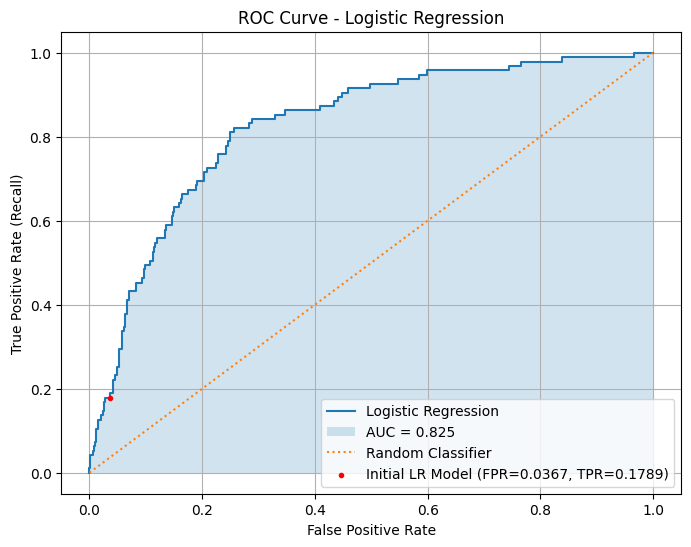

In [13]:
# Find the index where threshold is closest to 0.5
threshold_05_idx = np.argmin( # find minimum of code below
    np.abs(thresholds - 0.5) # get absolute difference of every threshold from 0.5
)

threshold_05_fpr = fpr[threshold_05_idx]
threshold_05_tpr = tpr[threshold_05_idx]

plt.figure(figsize=(8, 6))

plt.plot(
    fpr, # x-axis
    tpr, # y-axis
    label="Logistic Regression",
)

# Shade AUC area
plt.fill_between(fpr, tpr, alpha=0.2, label=f"AUC = {auc:.3f}")

# Random guessing baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    label="Random Classifier"
)

# Plot threshold = 0.5 point
plt.scatter(
    threshold_05_fpr, # x-axis coordinate
    threshold_05_tpr, # y-axis coordinate
    color="red",
    marker=".",
    zorder=5,
    label=f"Initial LR Model (FPR={threshold_05_fpr:.4f}, TPR={threshold_05_tpr:.4f})"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

### ROC Curve - Logistic Regression

The ROC curve plots every possible threshold's FPR/TPR tradeoff, giving a complete picture of model performance independent of any single threshold choice.

- The **blue** curve represents the model's performance across all thresholds. Moving up the curve shows the model catches more churners, but at the cost of more false alarms.

- The **shaded** area is the area under the ROC curve, a single score summarizing the curve. 0.825 means the model correctly identifies the at-risk churner **82.5%** of the time when comparing a random churner against a random non-churner.

- The **dotted** diagonal line essentially represents what a coin flip looks like. A well performing model's ROC curve should always sit above this line.

- The **red** dot represents our initial Logistic Regression model's performance on the graph of all of the other thresholds' scores. It rarely raises false alarms, but only catches less than **20%** of actual churners, which lines up with the confusion matrix.


### Custom Threshold Predictions

A convenvient feature of Logistic Regression is that once `predict_proba()` has been called, the probability scores are stored and can be reused. Applying a custom threshold is simply a boolean mask against the scores in the array. 

This returns **True** (predicted churn) for any score at or above the set threshold, and **False** for any score below. Since the computationally expensive step (predicting probability) is already done, changing the thresholds and re-evaluating is essentially a breeze.

The default Logistic Regression threshold in Scikit-Learn is **0.5**. Since customer churn prediction often prioritizes identifying as many churners as possible, even if it results in more false positives. We will lower the classfication threshold and evaluating model performance regarding those changes.

In [14]:
# Create predictions using a custom threshold
threshold = 0.30
y_pred_30 = (y_prob_churn >= threshold)

# Evaluate
accuracy_30 = accuracy_score(y_test, y_pred_30)
precision_30 = precision_score(y_test, y_pred_30)
recall_30 = recall_score(y_test, y_pred_30)
f1_30 = f1_score(y_test, y_pred_30)

print(f"Threshold : {threshold}")
print(f"Accuracy  : {accuracy_30:.4f}")
print(f"Precision : {precision_30:.4f}")
print(f"Recall    : {recall_30:.4f}")
print(f"F1 Score  : {f1_30:.4f}")

Threshold : 0.3
Accuracy  : 0.8516
Precision : 0.4778
Recall    : 0.4526
F1 Score  : 0.4649


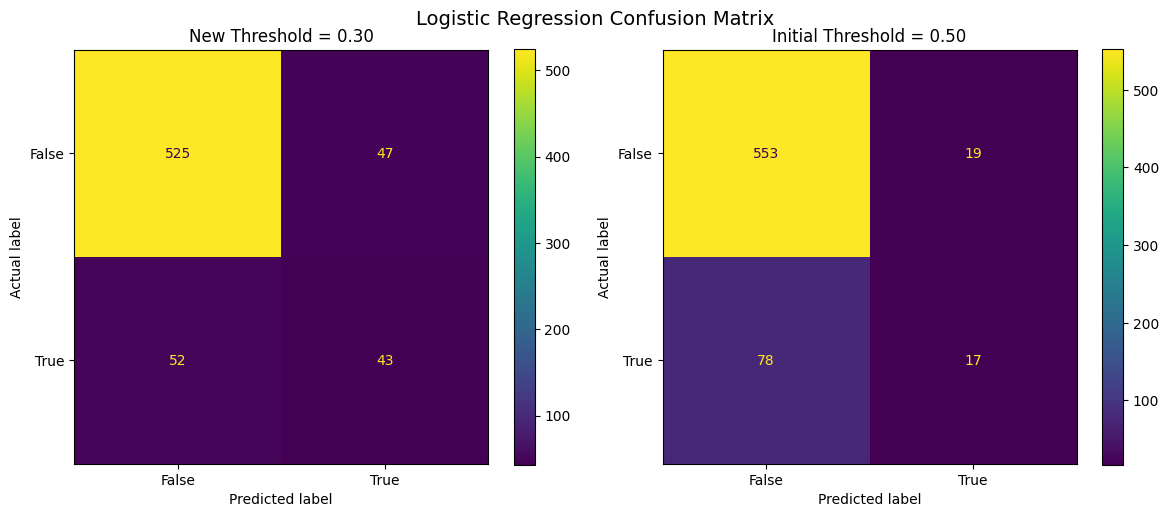

In [15]:
# Initialize confusion matrix for custom threshold
cm_30 = confusion_matrix(y_test, y_pred_30)

# Plot cm
disp_30 = ConfusionMatrixDisplay(
    confusion_matrix=cm_30,
    display_labels=lr.classes_
)

# Create 1 figure and axes list for 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Render cm in first subplot
disp_30.plot(ax=axes[0])
axes[0].set_title("New Threshold = 0.30")
axes[0].set_ylabel("Actual label")

# Render initial cm in second subplot
disp.plot(ax=axes[1])
axes[1].set_title("Initial Threshold = 0.50")
axes[1].set_ylabel("Actual label")

fig.suptitle("Logistic Regression Confusion Matrix", fontsize=14)
plt.tight_layout() # auto adjust subplot layout to avoid overlap
plt.show()

The results from the confusion matrix at threshold = 0.30:

- 525 actually `false`, predicted **false** (TN)

- 47 actually `false`, predicted **true** (FP)

- 52 actually `true`, predicted **false** (FN)

- 43 actually `true`, predicted **true** (TP)

Lowering the threshold to 0.30 meaningfully improved recall. Of the 95 actual churners, the model now correctly identifies 43. Since 43 / 95 ≈ 45.3%, the model catches nearly 1 in 2 churners, compared to less than 1 in 5 at the default 0.50 threshold.

This improvement comes from reducing false negatives from 78 to 52, allowing the model to identify 26 additional churners. As a key note, the Logistic Regression model itself did not change, only the threshold was adjusted.

The trade off is an increase in false positives. False positives rose from 19 to 47, decreasing overall accuracy slightly. However, for a churn prediction problem where missing an at-risk churner is often more costly than incorrectly flagging a loyal customer, this tradeoff is justified. The threshold of 0.30 provides a more balanced compromise between identifying churners and maintaining reasonable precision.

In [16]:
# Define thresholds from 0.10 to 0.50, increment by 0.05
thresholds = np.arange(0.10, 0.51, 0.05) 

results = []

# Iterate through thresholds and append metrics
for threshold in thresholds:
    y_pred_thresh = (y_prob_churn >= threshold)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_thresh),
        "Precision": precision_score(y_test, y_pred_thresh),
        "Recall": recall_score(y_test, y_pred_thresh),
        "F1": f1_score(y_test, y_pred_thresh)
    })

results_df = pd.DataFrame(results)

results_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.658171,0.276094,0.863158,0.418367
1,0.15,0.764618,0.349515,0.757895,0.478405
2,0.20,0.812594,0.401316,0.642105,0.493927
3,0.25,0.833583,0.434426,0.557895,0.488479
4,0.30,0.851574,0.477778,0.452632,0.464865
5,0.35,0.854573,0.484848,0.336842,0.397516
6,0.40,0.851574,0.464286,0.273684,0.344371
7,0.45,0.850075,0.439024,0.189474,0.264706
8,0.50,0.854573,0.472222,0.178947,0.259542


### Threshold Comparison
As expected, lowering the classification threshold increased recall. The model became less conservative when identifying churners, allowing it to capture a larger percentage of at-risk customers.

Precision naturally decreased as the threshold was lowered, but not as drastically as expected. This suggests that the model's probability estimates has useful insight and are not simply generation random positive predictions. This ties directly back to the model's relatively high AUC (0.825), the model genuinely predicts higher scores to real churners more often than not.

The F1 score peaked at threshold **0.20**, indicating the best overall balance between precision and recall in the dataset:
  - Recall = 64.2%
  - Precision = 40.1%
  - F1 Score = 49.4% (highest)

Threshold **0.50** was overly conservative and missed many churners, while a threshold **0.10** had the highest recall but introduced too many false positives to be justified.

### Business Oriented Evaluation
For customer churn prediction, recall is often prioritized because missing a customer who is likely to leave can be more costly than incorrectly flagging a loyal customer. However, precision remains iportant as excessive false positives may waste **retention** resources. 

Based on threshold comparison, **0.20** appears to be the most balanced operating threshold for this dataset, with **0.25** being a reasonable choice if maximizing our model's recall without ruining precision is a priority.


In [17]:
# Sort by F1 score
results_df.sort_values("F1", ascending=False).round(4)

,Threshold,Accuracy,Precision,Recall,F1
2,0.20,0.8126,0.4013,0.6421,0.4939
3,0.25,0.8336,0.4344,0.5579,0.4885
1,0.15,0.7646,0.3495,0.7579,0.4784
4,0.30,0.8516,0.4778,0.4526,0.4649
0,0.10,0.6582,0.2761,0.8632,0.4184
5,0.35,0.8546,0.4848,0.3368,0.3975
6,0.40,0.8516,0.4643,0.2737,0.3444
7,0.45,0.8501,0.4390,0.1895,0.2647
8,0.50,0.8546,0.4722,0.1789,0.2595


### Coefficients

The threshold analysis told us how well the model performs, but not **why** it makes the predictions it does. To understand that, we evaluate the model's coefficients.

During training, logistic regression assigned a weight to every feature. These weights, called **coefficients**, represent the direction and strength of each feature's influence on predicted churn probabilities. In our case:

- A **positive** coefficient means the feature is associated with a higher probability of churning
- A **negative** coefficient means the feature is associated with a higher probability of **not** churning
- Larger coefficient values indicate a **stronger** influence on the mode's predictions.
- A coefficient **near zero** means the feature has little to no influence on predictions.

A key advantage of Logistic Regression is that viewing features and their influence to predictions are relatively straighforward. This type of transparency is value in business context, where knowing **why** a customer is flagged as at-risk of churning is often more insightly then just knowing that they are.

In [18]:
# Get dataframe of coefficients
coef_df = pd.DataFrame({
    "Feature": X_train.columns, # feature name
    "Coefficient": lr.coef_[0] # correponding coefficient from 1d array
})

# Sort by absolute value of coefficient
coef_df.sort_values(
    by="Coefficient",
    ascending=False
).round(4)

,Feature,Coefficient
2,International plan,2.0388
5,Total day minutes,0.6753
13,Customer service calls,0.6572
7,Total eve minutes,0.2839
11,Total intl minutes,0.2767
4,Number vmail messages,0.2427
9,Total night minutes,0.1392
6,Total day calls,0.0559
10,Total night calls,0.0368
0,Account length,0.0350


### Coefficients Evaluation

- International Plan (**+2.04**) is the strongest positive predictor of churn, suggesting customers with an international plan are more likely to churn.

- Customer Service Calls (**+0.66**) is also a strong positive predictor, indicating customers who contact support more frequently tend to have a higher churn risk.

- Total Day Minutes (**+0.68**) suggests heavier daytime usage is associated with increased churn.

- Voice Mail Plan (**-1.39**) is the strongest negative predictor, suggesting customers with a voice mail plan are less likely to churn.

It is important to remember that coefficients describe **associations**, not causes. The model does not prove that a feature causes churn, it only indicates that the feature is related to churn behavior within this dataset. 

For example, the model suggests that customers with an international plan are more likely to churn, but it does **not** prove that the international plan itself causes customers to leave. It tells us the international plan could be associated with at-risk churners.

Coefficients can also be ranked by absolute value to measure influence regardless of direction, as a coefficient of -1.39 (Voice mail plan) is more influential than 0.28 (Total eve minutes).


### Odds Ratio

Odds ratios are the coefficients transformed via `np.exp(coef)`, converting from the abstract 
log-odds log (churn probability / not-churn probability) scale into a multiplicative scale that is easier to interpret:

- Odds ratio **> 1** — the feature is associated with higher churn odds
- Odds ratio **= 1** — no effect
- Odds ratio **< 1** — the feature is associated with lower churn odds

For example, an odds ratio of **2.0** means the odds of churning are twice as high for a one-unit 
increase in that feature. An odds ratio of **0.25** means the odds are **75%** lower.

Odds are not **probabilities**. An odds ratio of 7.7 does not mean the customer is 7.7x more likely to churn, It means the **odds** of churning multiply by 7.7. A 15% probability translates to odds of 0.15/0.85 = ~0.176. Multiplying odds by 7.7 does not produce the same result as multiplying the probability by 7.7

Association is not **causation**. A high odds ratio means a feature *correlates* with churn, 
not that it directly *causes* it. Other confounding variables outside the model may explain the relationship.



In [19]:
# New Odds Ratio column based on coefficient
coef_df["Odds Ratio"] = np.exp(coef_df["Coefficient"])

coef_df.sort_values(
    by="Odds Ratio",
    ascending=False
)

,Feature,Coefficient,Odds Ratio
2,International plan,2.038804,7.681418
5,Total day minutes,0.675269,1.964561
13,Customer service calls,0.657218,1.929418
7,Total eve minutes,0.283859,1.328245
11,Total intl minutes,0.276696,1.318765
4,Number vmail messages,0.242745,1.274744
9,Total night minutes,0.139159,1.149307
6,Total day calls,0.055890,1.057481
10,Total night calls,0.036820,1.037506
0,Account length,0.034953,1.035571


### Interpretation Reference
The coefficient of Customer service calls tells us that increasing that by 1 unit increases the log-odds of churn by 0.657. That's isnt easy to intrepret so we exponentiate to cancel out the log, getting an odds ratio of 1.929. We can interpret this as a 1 unit increase in customer service calls multiplies the odds of churn by ~1.93.

For international plan, since it's a binary encoded feature (only 0/1 entries), we interpret the odds ratio that customers with an international plan (1) have ~7.68x higher odds of churning than customers without an international plan (0). As good practice, we shouldn't assume that the international plan directly causes higher churn but that it's heavily correlated with higher risk of churn.

### Business Oriented Evaluation

The odds ratio highlight several features that are strongly associated with customer churn.

- **Internation plan** (OR = 7.68): An extreme outlier and the strongest predictor in the model. Looking independently, customers with an international plan had ~7.7x higher odds of churning than customers without. This suggests customers with an international plan may be experiencing pricing, service, or competition that increase churn risk.

- **Customer service calls** (OR = 1.93): Each additional customer service call multiplies the odds of churn by ~1.93. This may indicate that customers who repeatedly contact support are experiencing unresolved issues or discontent, making customer service interactions a potential early warning signal for churn.

- **Total day minutes** (OR = 1.96): Higher daytime usage is also associated with increased churn odds. This offers insight on the fact that heavy daytime users may be more sensitive to pricing, billing, or daytime service traffic affecting quality.

- **Voice mail plan** (OR = 0.25): Customers with a voice mail plan have ~75% lower odds of churning compared to customers without. This may suggest that customers who adopt additional services are naturally more incorporated with the business and therefore less likely to leave.

This findings identify factors associated with churn risk and offer insight on future retention strategies. It is imperative that the results are iterpreted as associative factors rather than evidence of direct causation.

## Final Conclusions

A Logistic Regression model was trained to predict customer churn and evaluated using accuracy, precision, recall, F1 score, confusion matrices, ROC analysis, and corresponding AUC.

The model achieved an AUC of approximately **0.825**, indicating strong capability to distinguish between churner and non-churners. While the default threshold **0.50** producted high accuracy, it missed many actual churners. Threshold tuning revealed that thresholds near **0.20** provided a better balance between precision and recall, greatly improving the model's ability to identify at-risk churners.

Feature interpretation showed that **Internation plan**, **Customer service calls**, and **Total day minutes** were among the strongest positive indicators of churn, while **Voice mail plan** was associated with lower churn risk. These insights may help with future customer retention efforts.

Overall, Logistic Regression proved effective and interpretable for churn prediction, as it provided both predictive performance and possibly crucial business insights.